# Quantity Analysis - Time Series

## Objective
Analyze and forecast **quantity trends** over time using time series analysis techniques.

## Dataset Overview
The dataset contains timestamped records of quantities sold or produced.

## Workflow
1. Load the data
2. Explore time-based patterns
3. Resample and smooth
4. Train a forecasting model
5. Visualize predictions

In [11]:
# Import necessary libraries

import pandas as pd 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error



### Data Loading & Inspection

In [2]:
# Load data from Excel file

file_path = "G:\My Projects\My Projects 2026\Feb Projects 2026\Data Science - Skillfied Mentor\Project 2 - Quantity Analysis Time Series Data\data/Raw Data_Predictive Analysis.xlsx"

df = pd.read_excel(file_path)

print(df.head())

print(df.info())


<>:3: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:3: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\ratho\AppData\Local\Temp\ipykernel_7228\1869956228.py:3: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  file_path = "G:\My Projects\My Projects 2026\Feb Projects 2026\Data Science - Skillfied Mentor\Project 2 - Quantity Analysis Time Series Data\data/Raw Data_Predictive Analysis.xlsx"


   OrderDate  ParentProductIdNew ParentProductNew ProductCategoryNew  \
0 2019-01-01                  11       Product 11         Category 1   
1 2019-01-01                 114      Product 114         Category 8   
2 2019-01-01                  98       Product 98         Category 8   
3 2019-01-01                  97       Product 97         Category 8   
4 2019-01-01                   8        Product 8         Category 1   

  ArtistNameNew  total_qty_sales  Selling Price  productListViews  \
0         TSSOS                3          399.0               NaN   
1          TSSA               10          549.0               NaN   
2         TSSHT                8          499.0               NaN   
3          TSSF                6          549.0               NaN   
4         TSSML                6          399.0               NaN   

   productListClicks  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  
<class 'pandas

## Exploratory Data Analysis

Number of Duplicate Rows Found: 0
Statistical Summary of Numerical Columns:


,OrderDate,ParentProductIdNew,total_qty_sales,Selling Price,productListViews,productListClicks
count,40563,40563.000000,40563.000000,40563.000000,25591.000000,25591.000000
mean,2020-03-15 13:02:53.330375,62.087863,14.335453,607.727903,8860.939940,215.843265
min,2019-01-01 00:00:00,1.000000,1.000000,99.000000,1.000000,0.000000
25%,2019-10-28 00:00:00,31.000000,3.000000,449.000000,2451.000000,38.000000
50%,2020-04-05 00:00:00,65.000000,8.000000,499.000000,5026.000000,84.000000
75%,2020-09-02 00:00:00,97.000000,16.000000,644.161290,11441.000000,204.000000
max,2020-12-31 00:00:00,114.000000,4144.000000,2994.000000,219578.000000,19657.000000
std,NaN,36.550756,34.820774,282.939037,10627.960951,499.114425


Missing Values in Each Column:
OrderDate                 0
ParentProductIdNew        0
ParentProductNew          0
ProductCategoryNew        0
ArtistNameNew             0
total_qty_sales           0
Selling Price             0
productListViews      14972
productListClicks     14972
dtype: int64
   OrderDate  total_qty_sales
0 2019-01-01              293
1 2019-01-02              351
2 2019-01-03              319
3 2019-01-04              341
4 2019-01-05              308


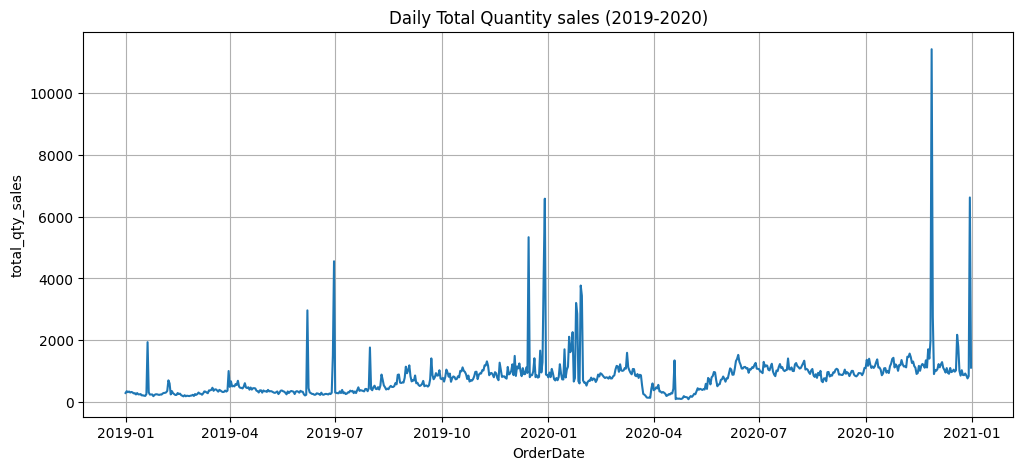

In [3]:
# Convert to datetime if necessary

# This conversion is not required here as pandas automatically detected the 'Date' column as datetime when reading the Excel file. If it were not detected, we would use the following code:
# df['Date'] = pd.to_datetime(df['Date'])

# checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of Duplicate Rows Found: {duplicates}")

# Removing duplicate rows if any

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates Removed!")

# Getting a statistical summary of Numerical columns
print("Statistical Summary of Numerical Columns:")
display(df.describe())

# Checking for the missing values in each column
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

# Checking for total quantity sold per day (Aggregation)
# This is our first step toward Time Series proper!

daily_sales = df.groupby('OrderDate')['total_qty_sales'].sum().reset_index()
print(daily_sales.head())

# Plot raw time series

plt.figure(figsize=(12,5)) 
sns.lineplot(data=daily_sales, x='OrderDate', y='total_qty_sales')
plt.title('Daily Total Quantity sales (2019-2020)')
plt.grid(True)
plt.show()


## Time Series Structuring (Resampling)

In [4]:
# Creating a new dataframe with 'OrderDate' as index and 'total_qty_sales' as the column for time series analysis

daily_df = df.groupby('OrderDate')['total_qty_sales'].sum().reset_index()

# Set date as index

daily_df.set_index('OrderDate', inplace=True)

# Ensuring that we have a continuous date range (filling missing dates with 0 sales)
# 'D' stands for daily frequency

daily_df = daily_df.asfreq('D', fill_value=0)

# Checking the first 10 rows of the newly created time series dataframe

print("Newly Structured Daily DataFrame for Time Series Analysis:")
display(daily_df.head(10))

# Verifying the new dataframe structure

print("\nNew Data Shape:", daily_df.shape)



Newly Structured Daily DataFrame for Time Series Analysis:


,total_qty_sales
OrderDate,
2019-01-01,293
2019-01-02,351
2019-01-03,319
2019-01-04,341
2019-01-05,308
2019-01-06,327
2019-01-07,311
2019-01-08,280
2019-01-09,288



New Data Shape: (731, 1)


## DECOMPOSING


Decomposition Completed and Plotted!


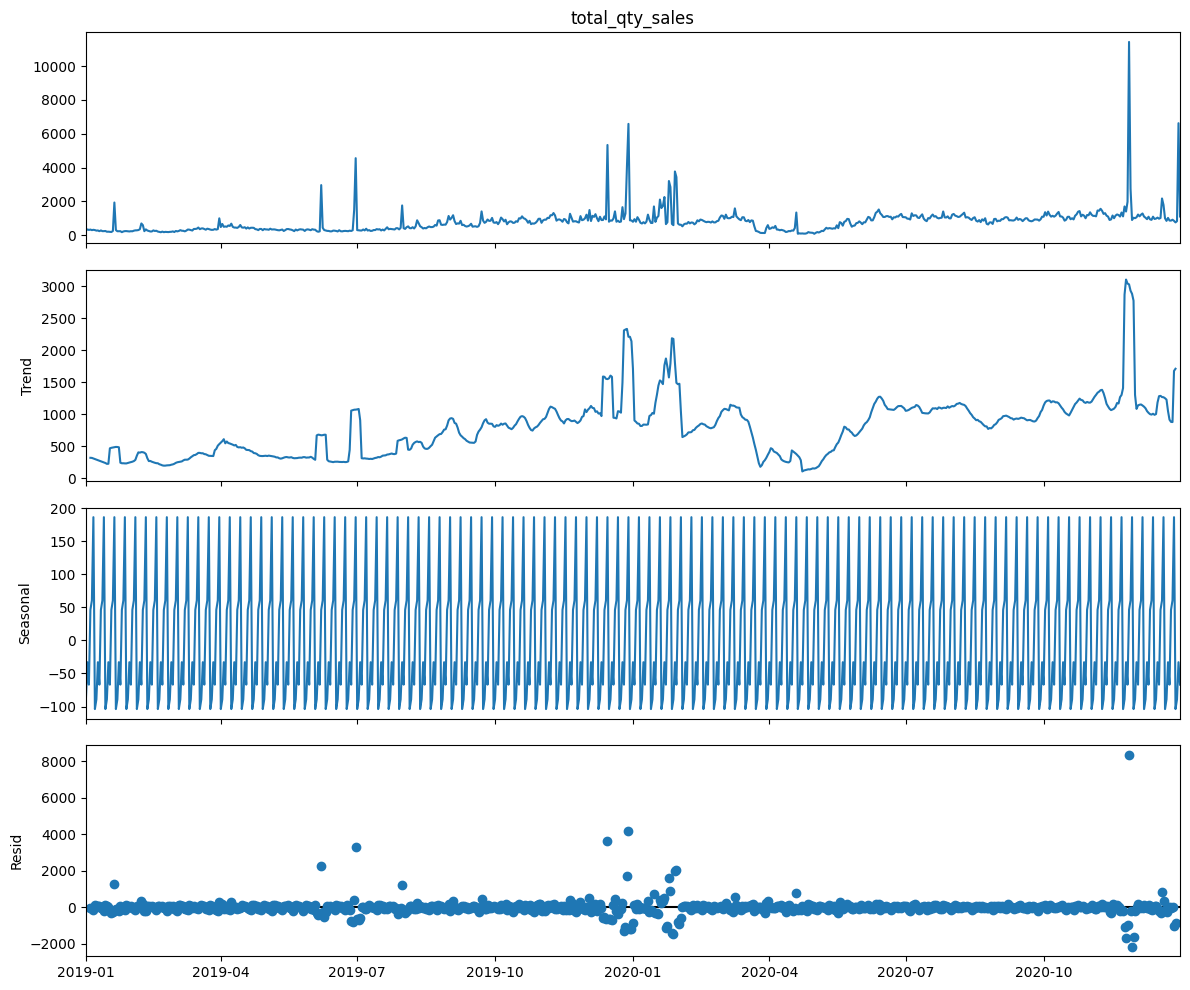

In [5]:
# Performing Deomposition to analyze trend, seasonality, and residuals
# period=7 is used to capture weekly seasonality

decomposition = seasonal_decompose(daily_df['total_qty_sales'], model='additive', period=7)

# Plotting the decomposed components

plt.rcParams['figure.figsize'] = (12, 10)
decomposition.plot()
print("Decomposition Completed and Plotted!")
plt.show()


## Stationarity & Statistical Checks

## Section Objective

To mathematically prove if our data's properties (mean and variance) stay constant over time.

In [6]:
# Running the Augmented Dickey-Fuller test to check for stationarity

print("Results of Augmented Dickey-Fuller Test:")
result = adfuller(daily_df['total_qty_sales'])

# Extracting and printing the test statistic and p-value

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# Interpretation of results

if result[1] < 0.05:
    print("\n✅ Result: The data is stationary. We can proceed to ARIMA!")
else:
    print("\n❌ Result: The data is not stationary. We need to to apply 'Differencing' on the data before ARIMA.")

Results of Augmented Dickey-Fuller Test:
ADF Statistic: -3.1069906151072333
p-value: 0.026040158512011774

✅ Result: The data is stationary. We can proceed to ARIMA!


## Data Splitting (Train-Test Split)

Total Days: 731
Training Days (The Past): 584
Testing Days (The Future We Want to Predict): 147


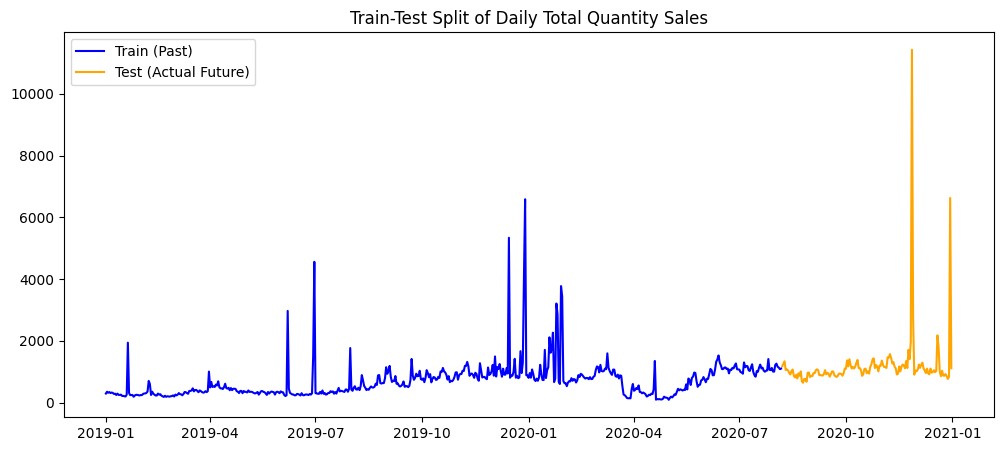

In [7]:
# Train-test split 
# Determine the split point (80% for training, 20% for testing)

train_size = int(len(daily_df) * 0.8)

# Splitting the data chronologically 

train = daily_df.iloc[:train_size]
test = daily_df.iloc[train_size:]

print(f"Total Days: {len(daily_df)}")
print(f"Training Days (The Past): {len(train)}")
print(f"Testing Days (The Future We Want to Predict): {len(test)}")

# Visualizing The Split 

plt.figure(figsize=(12,5))
plt.plot(train.index, train['total_qty_sales'], label='Train (Past)', color='blue')
plt.plot(test.index, test['total_qty_sales'], label='Test (Actual Future)', color='Orange')
plt.title('Train-Test Split of Daily Total Quantity Sales')
plt.legend()
plt.grid(False)
plt.show()

## Model Selection (Acf & Pacf Plots)

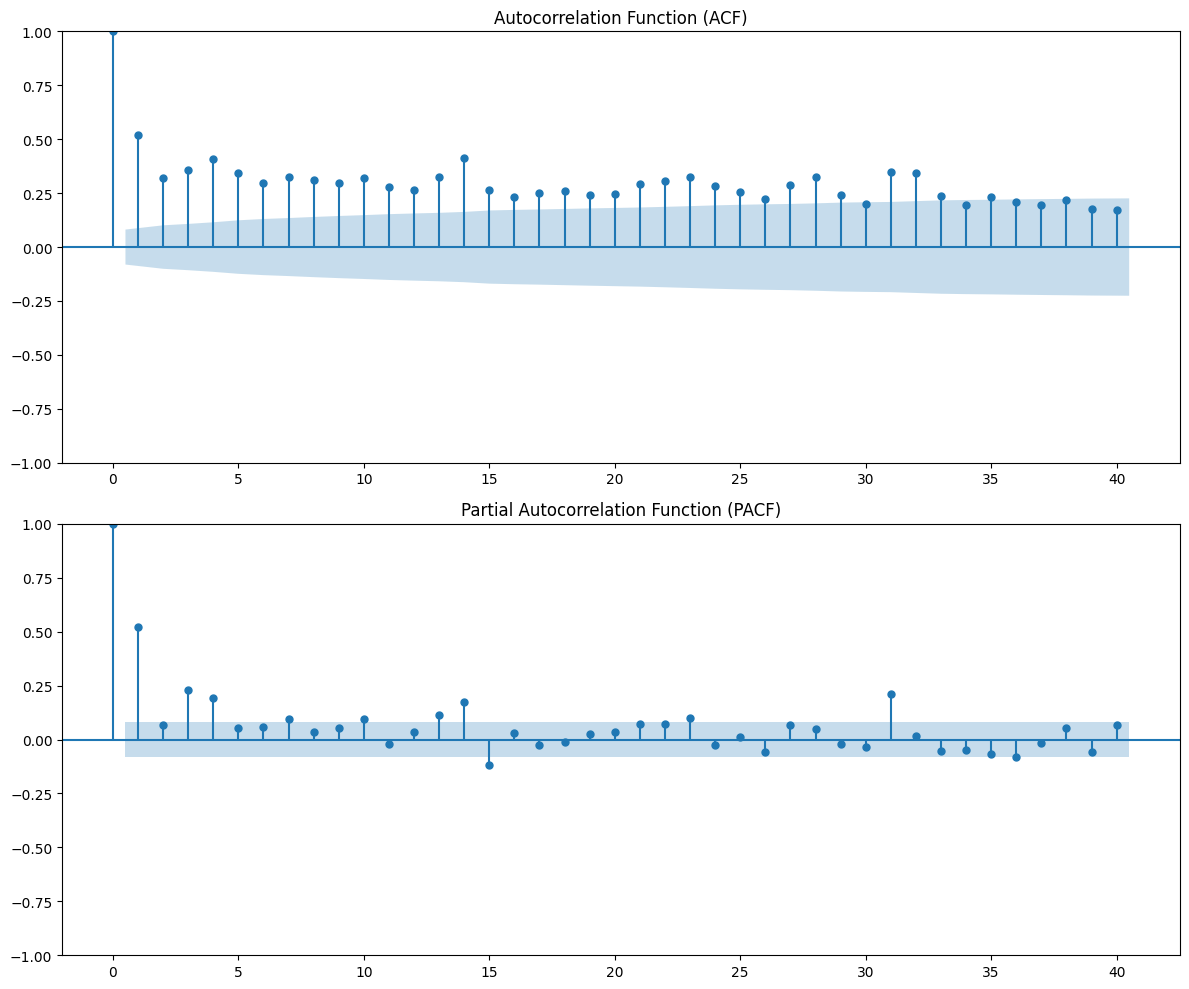

In [8]:
# Creating a figure with 2 subplots for ACF and PACF

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10))

# Plot ACF to find the value of 'q' (MA order)

plot_acf(train['total_qty_sales'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation Function (ACF)')

# Plot PACF to find the value of 'p' (AR order)

plot_pacf(train['total_qty_sales'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

## Modeling with ARIMA

In [9]:
# Defining the ARIMA model with the identified parameters (p, d, q)
# p=2 (PACF bars), d=0 (Stationary), q=2 (Starting guess based on ACF)

order = (2, 0, 2)

# Initializing the ARIMA model on the training data with the specified order (p, d, q)

model = ARIMA(train['total_qty_sales'], order=order)

# Fit ARIMA model

model_fit = model.fit()

# Forecast - Printing the professional summary of the fitted ARIMA model

print("ARIMA model summary:")
print(model_fit.summary())


ARIMA model summary:
                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  584
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -4412.426
Date:                Sat, 14 Mar 2026   AIC                           8836.853
Time:                        10:48:56   BIC                           8863.072
Sample:                    01-01-2019   HQIC                          8847.072
                         - 08-06-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        695.5837    320.735      2.169      0.030      66.954    1324.214
ar.L1          0.9048      0.103      8.751      0.000       0.702       1.107
ar.L2          0.0830      0.09

## Evaluation and Visualization

Model Evaluation Metrics:
Mean Absolute Error (MAE):  366.33
Root Mean Squared Error (RMSE):  1066.25


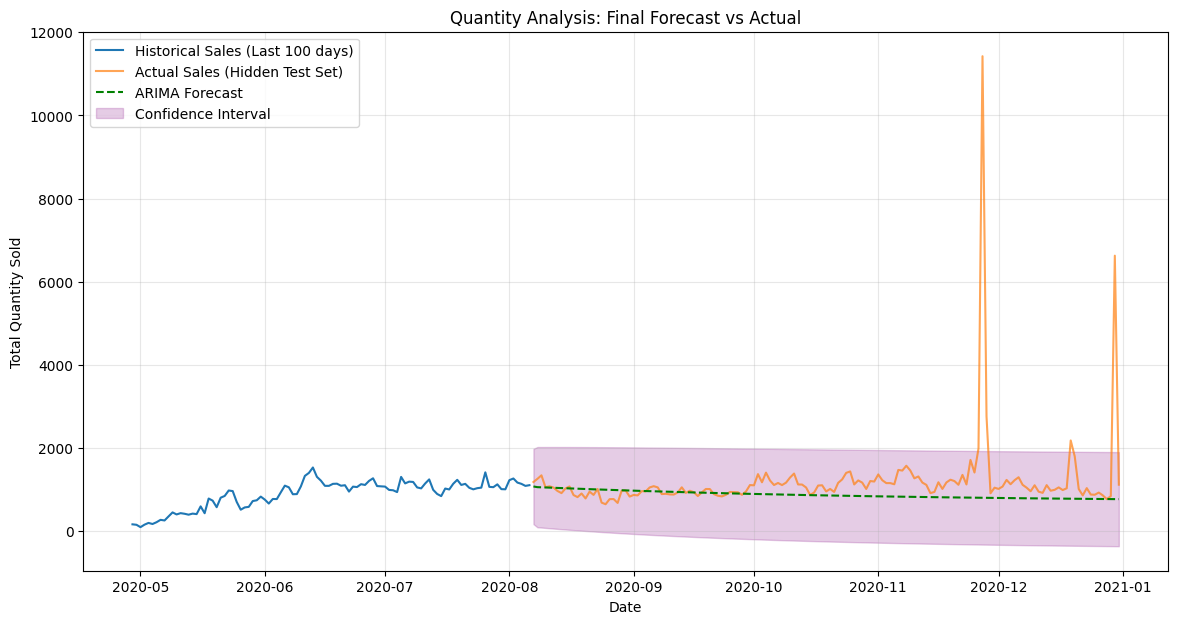

In [10]:
# Forecast for the test period (the 20% we hide)

forecast_steps = len(test)
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Calculating the evaluation metrics (MSE and MAE)

mae = mean_absolute_error(test['total_qty_sales'], forecast_values)
rmse = np.sqrt(mean_squared_error(test['total_qty_sales'], forecast_values))

print(f"Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae: .2f}")
print(f"Root Mean Squared Error (RMSE): {rmse: .2f}")

# Final Professional Visualization of Forecast vs Actual

plt.figure(figsize=(14,7))
plt.plot(train.index[-100:], train['total_qty_sales'].tail(100), label="Historical Sales (Last 100 days)", color='#1f77b4')
plt.plot(test.index, test['total_qty_sales'], label='Actual Sales (Hidden Test Set)', color='#ff7f0e', alpha=0.7)
plt.plot(test.index, forecast_values, label='ARIMA Forecast', color='green', linestyle='--')

# Plot confidence intervals (The Safety Zone)
plt.fill_between(test.index, confidence_intervals.iloc[:,0], confidence_intervals.iloc[:,1], color='purple', alpha=0.2, label='Confidence Interval')
plt.title('Quantity Analysis: Final Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




## Business Summary

- Project Achievement: "Developed a Time Series forecasting model using ARIMA(2,0,2) to predict daily product demand."
- Accuracy: "Achieved an MAE of 366.33, allowing the business to estimate inventory needs with a known margin of error."
- Key Insight: "Identified a strong 7-day seasonal cycle and an upward growth trend in sales volume from 2019 to 2020."